In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score

from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

import pandas as pd

## 1. Выбор датасета
https://www.kaggle.com/datasets/uciml/glass - датасет классификации типов стекла

Type of glass:
- 1 building_windows_float_processed 
- 2 building_windows_non_float_processed
- 3 vehicle_windows_float_processed
- 4 vehicle_windows_non_float_processed (none in this database)
- 5 containers
- 6 tableware 
- 7 headlamps

## 2. EDA


признаки (Na, Mg, ... Fe) - отображают массовую долю в соответсвующем оксиде, измеряется в процентах.

RI - refractive index

In [2]:
df = pd.read_csv("glass.csv")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [3]:
print(df.isna().sum())
df.shape

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


(214, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [5]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [6]:
df['Type'].value_counts().sort_values()

Type
6     9
5    13
3    17
7    29
1    70
2    76
Name: count, dtype: int64

Классы сильно отличаются по размеру - ну чето плохо

In [7]:
'''

удалить дубликаты объектов

'''

df = df.drop_duplicates()
df.shape

(213, 10)

C:\Users\admin\AppData\Local\Temp\ipykernel_2960\997537963.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=column, hue='Type', multiple="stack")
C:\Users\admin\AppData\Local\Temp\ipykernel_2960\997537963.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=column, hue='Type', multiple="stack")
C:\Users\admin\AppData\Local\Temp\ipykernel_2960\997537963.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=column, hue='Type', multiple="stack")


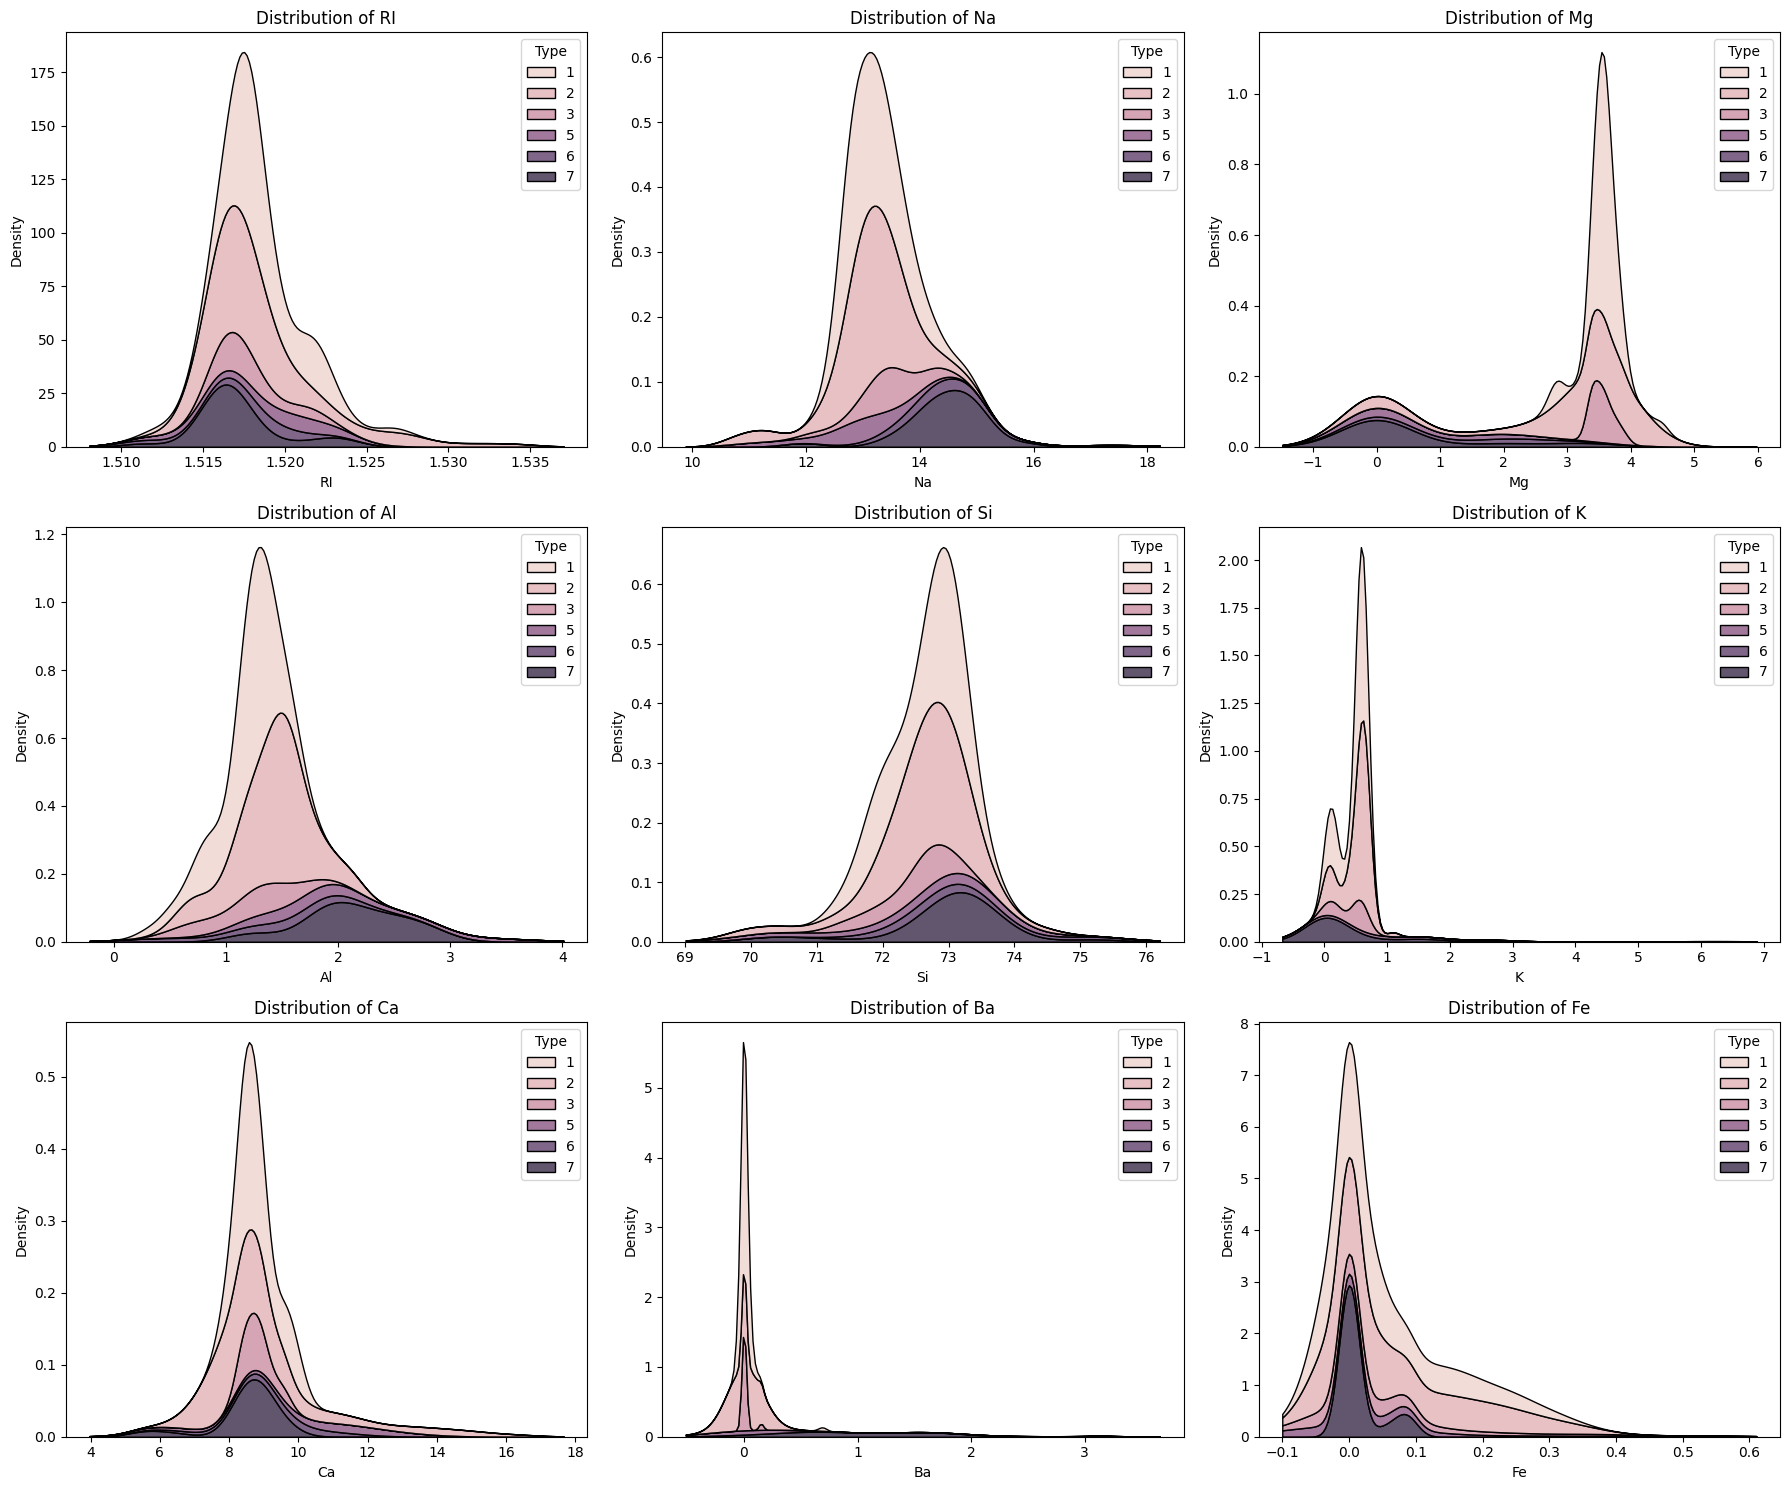

In [8]:
plt.figure(figsize=(18, 15))
stats_summary = []
columns = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

for i, column in enumerate(columns, 1): 
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=column, hue='Type', multiple="stack")
    plt.title(f'Distribution of {column}')
    column_stats = df.groupby('Type')[column].agg(['skew', 'kurt']).reset_index()
    column_stats['Feature'] = column
    stats_summary.append(column_stats)

plt.tight_layout()
plt.show()

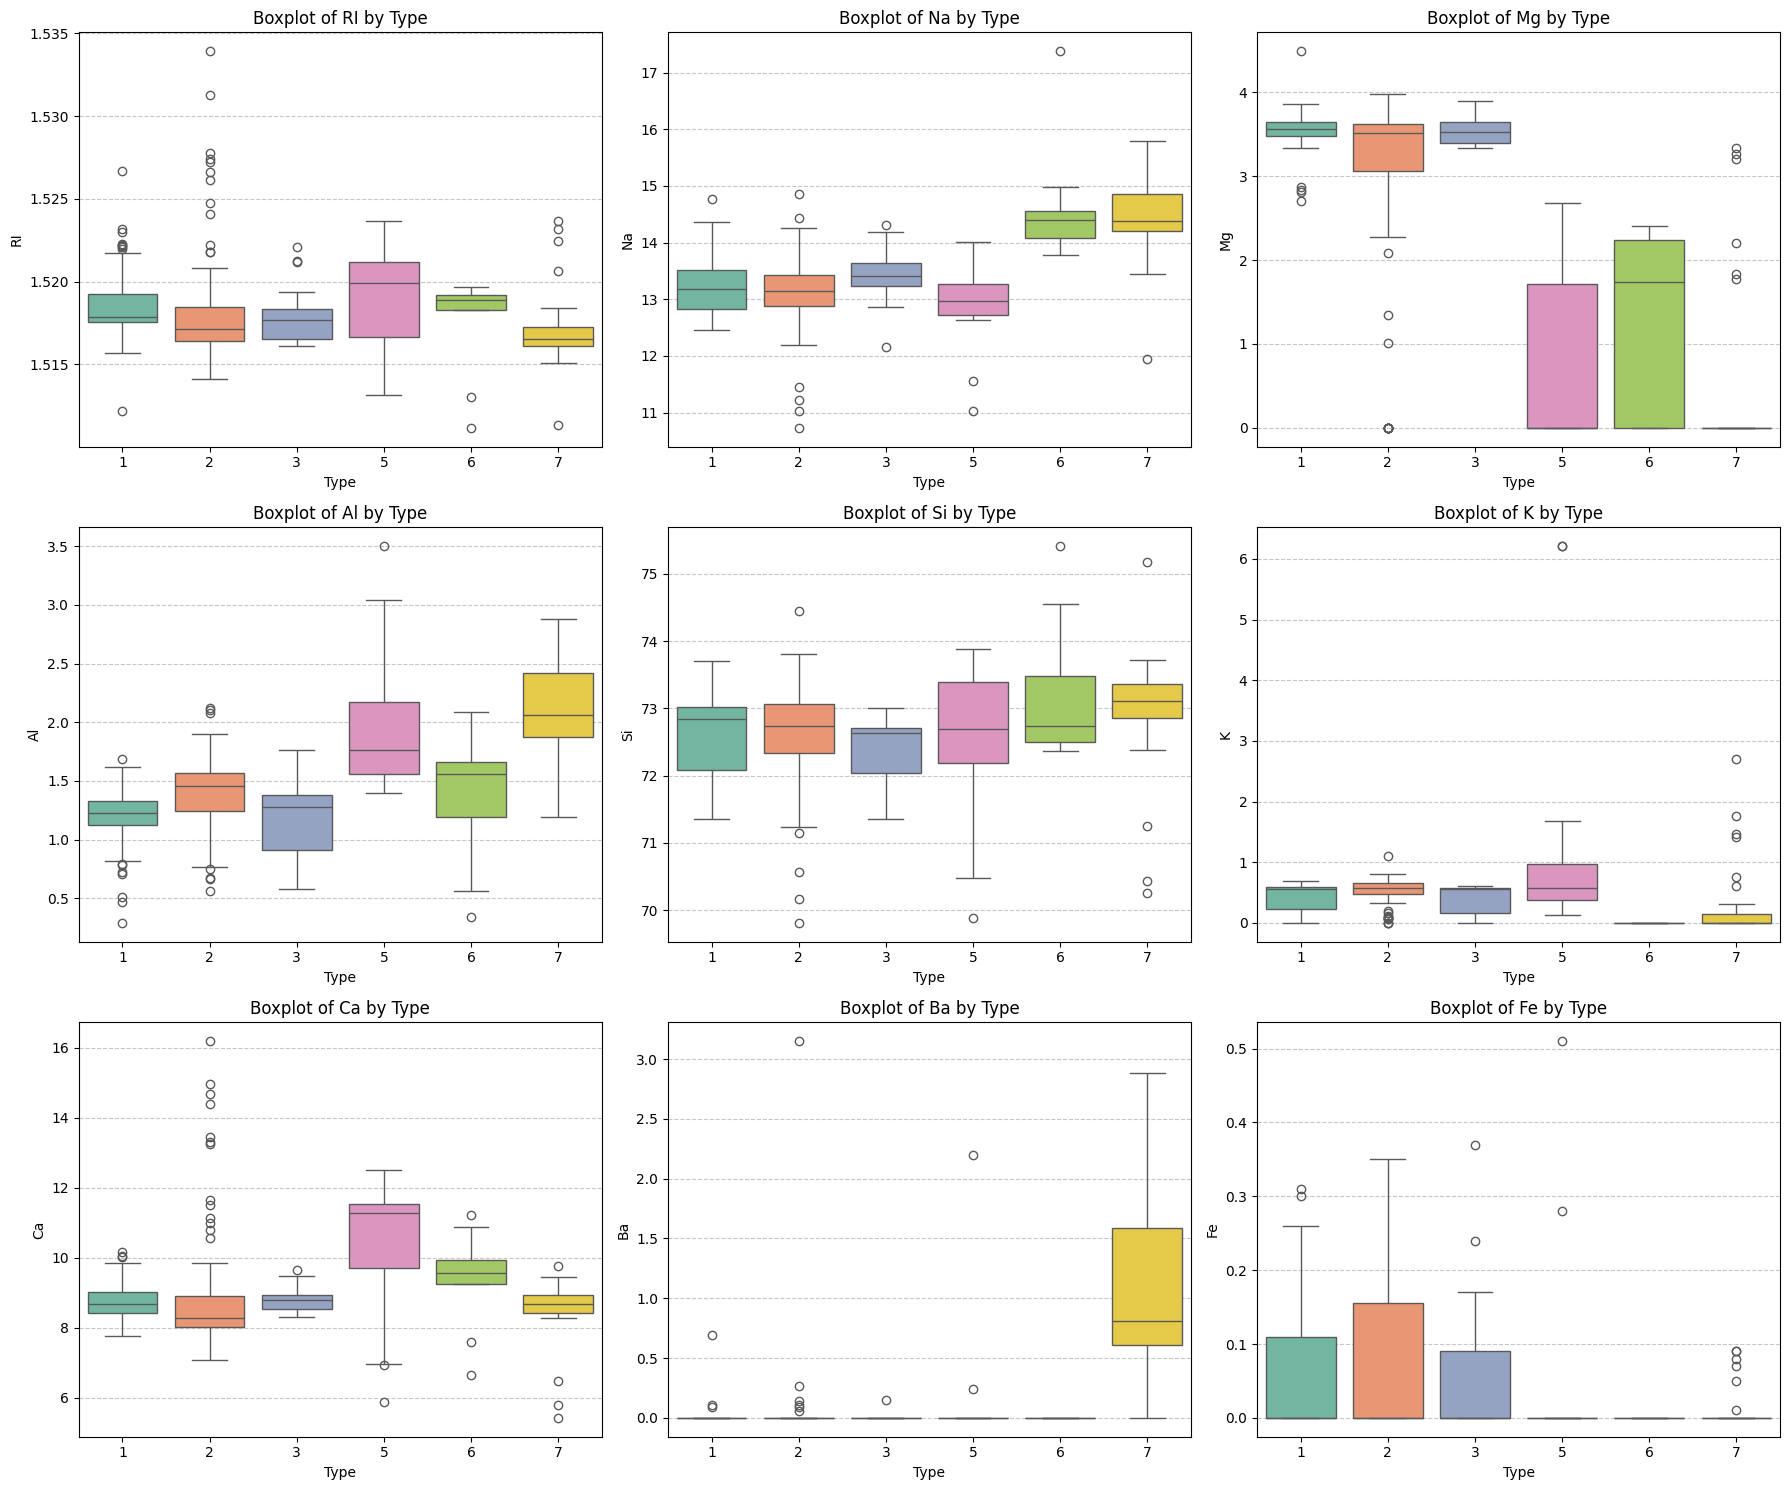

In [9]:
plt.figure(figsize=(18, 15))

for i, column in enumerate(columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='Type', y=column, palette='Set2', hue='Type', legend=False)
    
    plt.title(f'Boxplot of {column} by Type', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

- ri ничем не выделяется для разынх типов
- по Na 6, 7 типы выше содержанием.
- по Mg 1, 2, 3 классы выше содеражнием
- по Al 5, 7 классы
- Si все одинаково
- K указывает на большее содержание в 5 классе и отсутствие в 6
- Ca на повышененое соедржание в 5 классе
- Ba - однозначно 7 класс
- Fe в среднем для всех клаасов низкая концентрация. Классы 1, 2, 3 хоть как выделились


можно предположить, что классифицировать 1, 2, 3 классы будет проблематично, однако посмотрев на график ниже kde 

In [ ]:

plt.figure(figsize = (20,40))

columns = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']

for i, column in enumerate(columns, 1): 
    plt.subplot(5, 2, i)


    sns.kdeplot(df[column][df.Type == 1], fill=True)
    sns.kdeplot(df[column][df.Type == 2], fill=True)
    sns.kdeplot(df[column][df.Type == 3], fill=True)

    plt.title(f'Distribution of {column}')
    plt.legend(['Type 1', 'Type 2', 'Type 3'])

plt.tight_layout()

plt.show()

по разным признакам совпадает или распределение 1 и 3 (Ba, Ca, Al, Mg, RI) или 2 и 3 (Fe, Si)

Шанс что классификатор сможет классифицировать эти классы есть

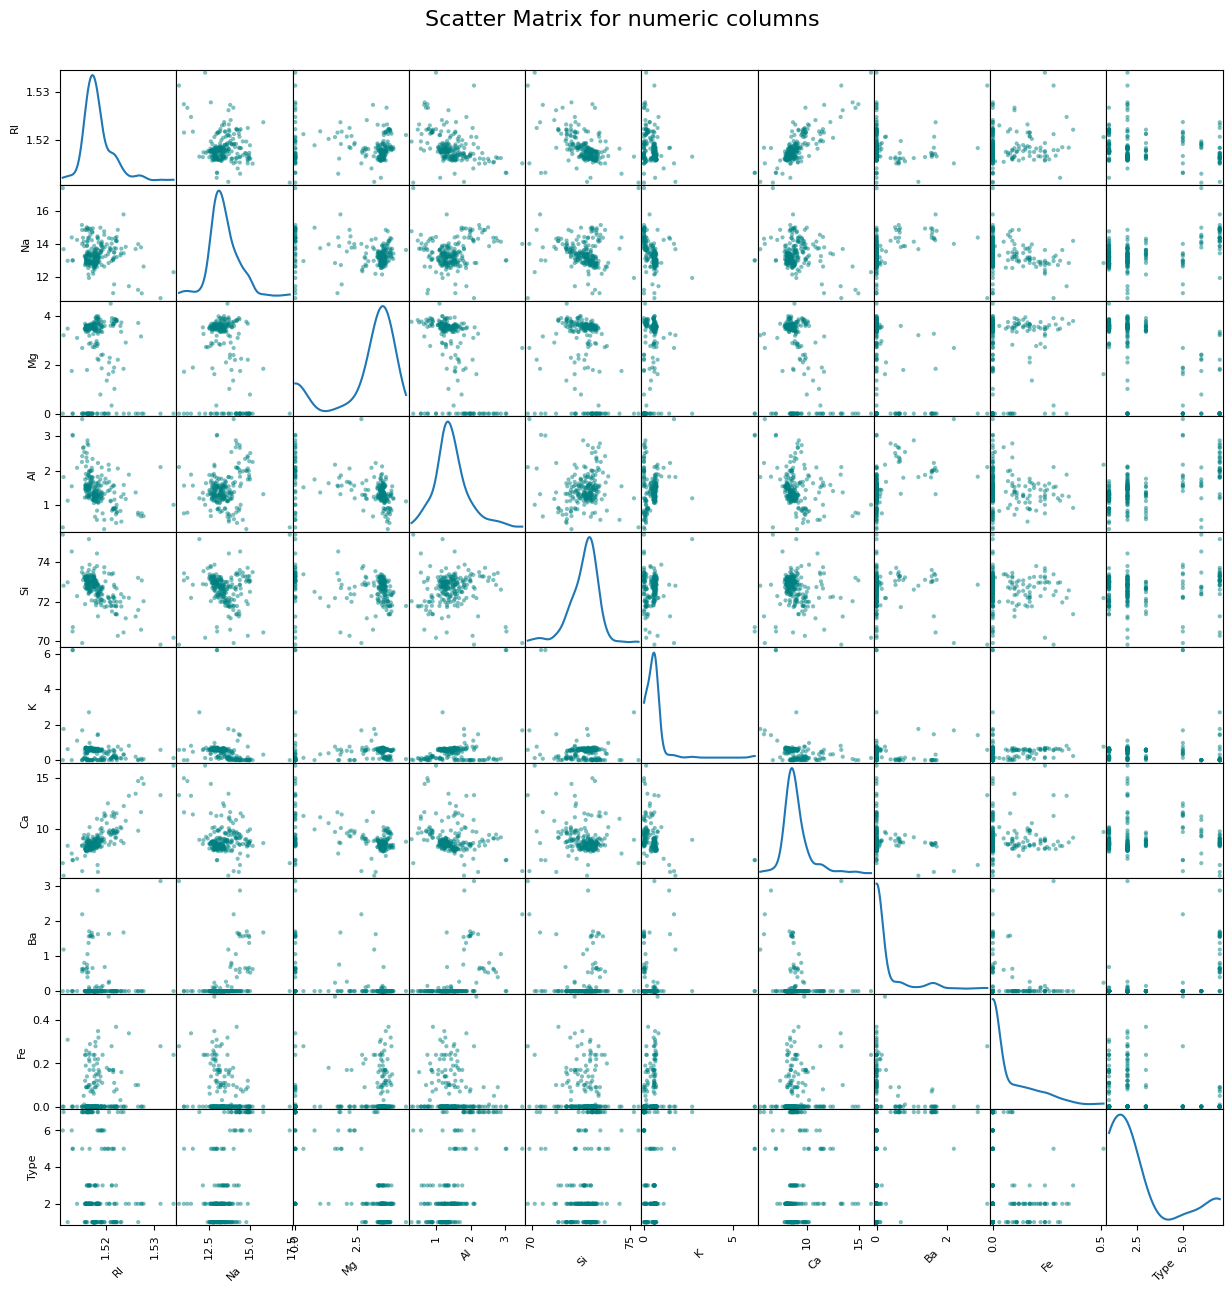

In [ ]:

sm = pd.plotting.scatter_matrix(
    df, 
    figsize=(15, 15), 
    diagonal='kde',
    alpha=0.5,
    color='teal',
    grid=True
)

for ax in sm.ravel():
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=45)
    ax.set_ylabel(ax.get_ylabel(), fontsize=8, rotation=90)

plt.suptitle('Scatter Matrix for numeric columns', size=16, y=0.92)
plt.show()

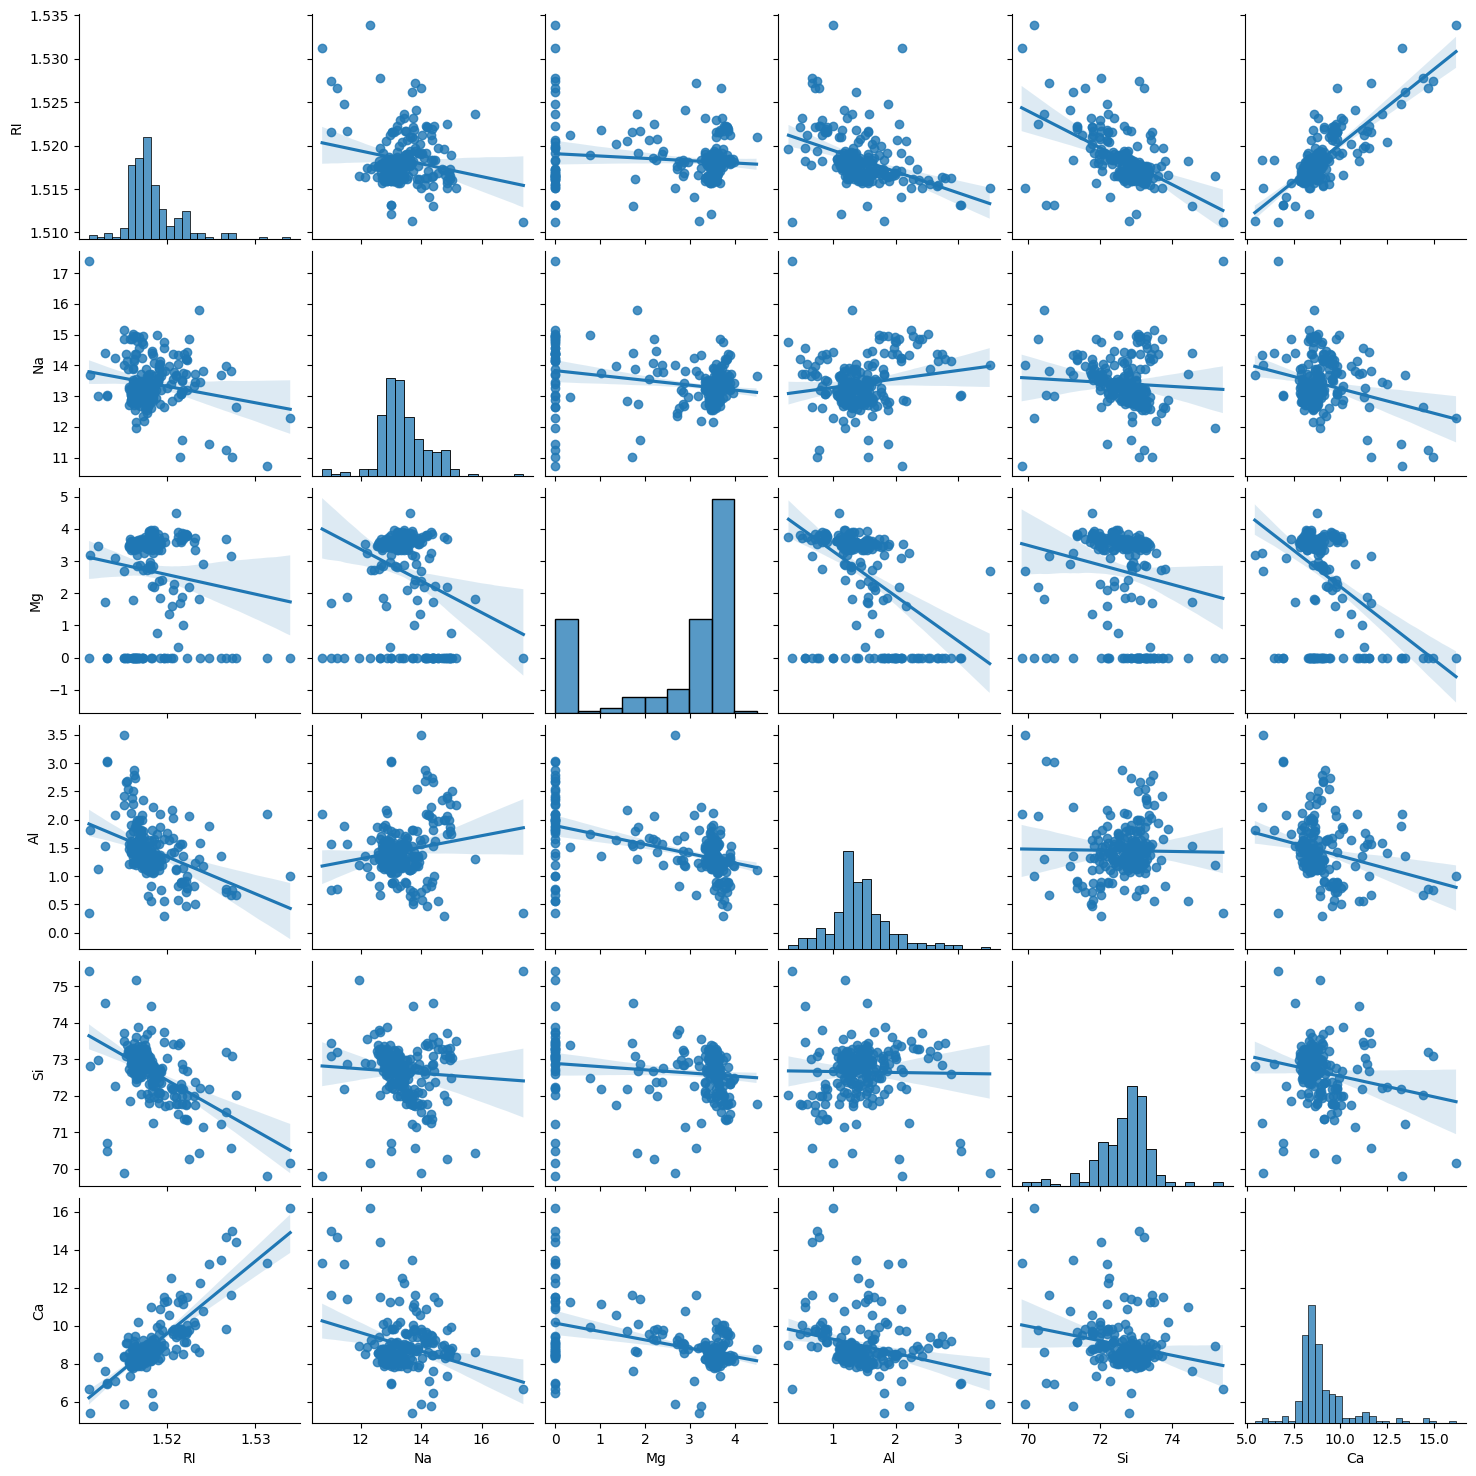

In [ ]:
sns.pairplot(df[['RI','Na','Mg','Al','Si','Ca']], kind='reg')

видна линейная связь между Ca и RI

<Axes: >

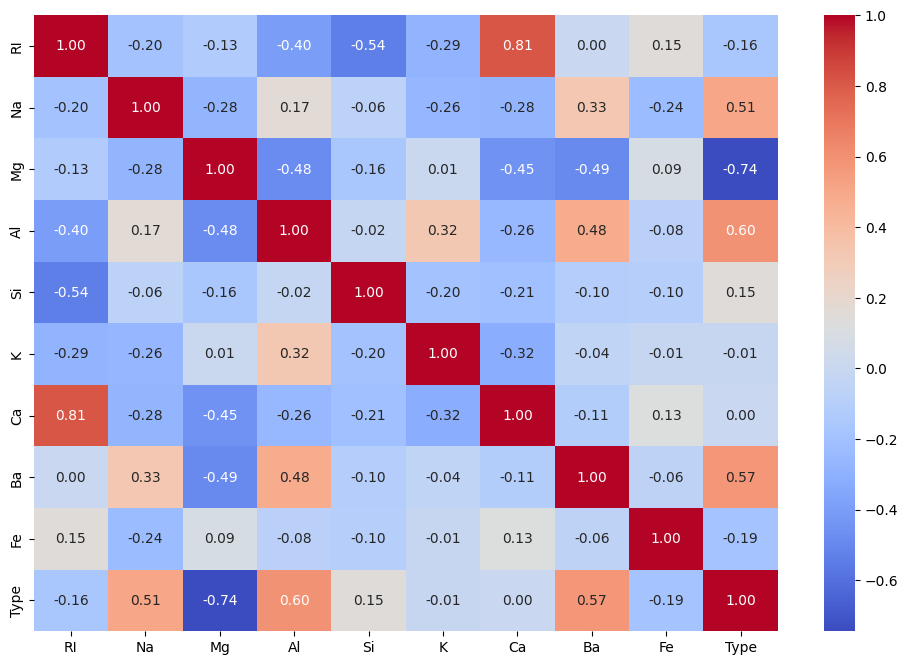

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

<Axes: xlabel='Type', ylabel='count'>

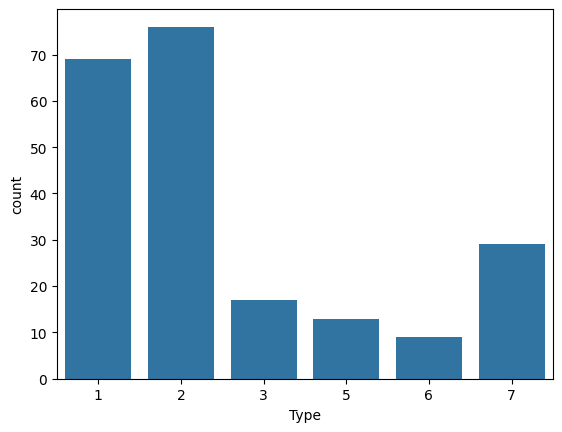

In [ ]:
sns.countplot(x=df['Type'], data=df)

несбалансированны классы.

есть стратегии oversampling undersampling - хз че надо. сначал обучим просто

### ИТОГ EDA
выше ўсё показано

- небольшой датасет на 214 строк
- удален 1 дубликат.
- все признаки числовые.
- выходных классов 1-7 (не представлен 4)
- классы несбалансированы - особенно в 6 классе 9 элементов, в 2 больше 70 
- распределение значений признаков по классам не одинаковов, также данные смещены
- есть выбросы
- смещеение части данных к 0
- в большинстве признаков по графикам значение пика совпадает - признаки скореллированы
- Руками по box-plt и kde были найдены признаки для разделения на классы и виды распределения есть надежда что все классифицируется


## 3. Подготовка данных



- масштабирование признаков - через 3 разыне функции
- разделение на train / test - необходимо чтобы и в тестовой и в обучающей выборке были элементы из каждого класса

почему масштабирование важно для KNN - ближайшие соседи ищутся по метрике, очев бессмысленно если есть очень большие признаки(значения намного больше чем у других). Тк большие признаки будут перетягивать на себя решение модели.

почему нельзя подбирать параметры на тестовой выборке - утечка данных


In [ ]:
X = df.drop(columns='Type')
y = df['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((149, 9), (64, 9), (149,), (64,))

In [ ]:
print(np.unique(y_train))
print(np.unique(y_test))

[1 2 3 5 6 7]
[1 2 3 5 6 7]


маштабирование через стандартизацию $x = \frac{x-mean}{std}$ then mean = 0, std = 1

In [ ]:
scaler = StandardScaler()
X_train_std_scal = scaler.fit_transform(X_train)
X_test_std_scal = scaler.transform(X_test)

маштабирование через нормализацию $x = \frac{x-min}{max - min}$ then $x\in[0, 1]$

In [ ]:
scaler1 = MinMaxScaler()
X_train_mm_scal = scaler1.fit_transform(X_train)
X_test_mm_scal = scaler1.transform(X_test)

маштабирование через RobustScaler $x = \frac{x_{median}}{Q_3 - Q_1}$

In [ ]:
scaler2 = RobustScaler()
X_train_robust = scaler2.fit_transform(X_train)
X_test_robust = scaler2.transform(X_test)

## 4. Обучение KNN

Для разнообразия бдует приведено сравнение всех возможных knn с разными маштабированиями, параметрами

1. knn без маштабирования

In [ ]:
knn0 = KNeighborsClassifier(n_neighbors=6, weights='distance')
knn0.fit(X_train, y_train)
y_pred = knn0.predict(X_test)
knn0.score(X_test,y_test)

0.703125

In [ ]:
balanced_accuracy_score(y_test, y_pred)

0.686026936026936

поскольку классы несбалансированы, то правдивее balanced_accuracy_score = $\frac{1}{C} * \sum_{k=1}^C \frac{TP}{TP+FN}$

[[16  2  0  0  0  0]
 [ 7 14  1  1  1  0]
 [ 3  0  1  0  0  0]
 [ 0  0  0  4  0  0]
 [ 0  1  0  0  2  0]
 [ 0  2  0  1  0  8]]


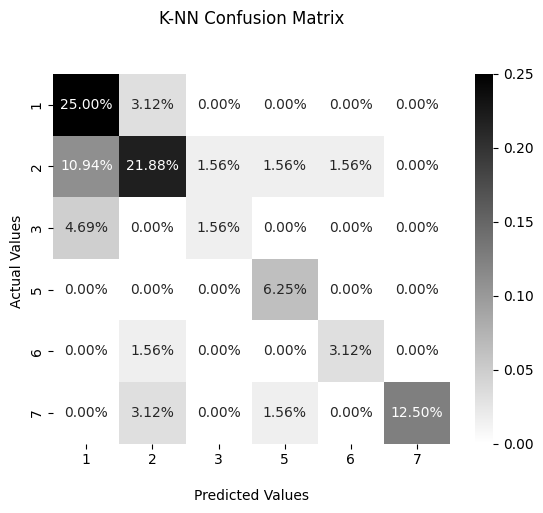

In [ ]:
cf_matrix_knnc = confusion_matrix(y_test, y_pred)
print(cf_matrix_knnc)


ax = sns.heatmap(cf_matrix_knnc/np.sum(cf_matrix_knnc), annot=True, fmt='.2%', cmap='binary', annot_kws={"size": 10})
ax.set_title('K-NN Confusion Matrix\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');


ax.xaxis.set_ticklabels(['1', '2', '3', '5', '6', '7'])
ax.yaxis.set_ticklabels(['1', '2', '3', '5', '6', '7'])

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

print('Accuracy Score : ' + str(round(accuracy_score(y_test,y_pred),3)))
print('Precision Score : ' + str(round(precision_score(y_test,y_pred, average='micro'),3)))
print('Recall Score : ' + str(round(recall_score(y_test,y_pred, average='micro'),3)))
print('F-Score : ' + str(round(f1_score(y_test,y_pred, average='micro'),3)))

              precision    recall  f1-score   support

           1       0.62      0.89      0.73        18
           2       0.74      0.58      0.65        24
           3       0.50      0.25      0.33         4
           5       0.67      1.00      0.80         4
           6       0.67      0.67      0.67         3
           7       1.00      0.73      0.84        11

    accuracy                           0.70        64
   macro avg       0.70      0.69      0.67        64
weighted avg       0.73      0.70      0.70        64

Accuracy Score : 0.703
Precision Score : 0.703
Recall Score : 0.703
F-Score : 0.703


In [ ]:
knn_std = KNeighborsClassifier(n_neighbors=6, weights='distance')
knn_std.fit(X_train_std_scal, y_train)
y_pred_std = knn_std.predict(X_test_std_scal)
accuracy_score(y_test, y_pred_std)

0.75

In [ ]:
balanced_accuracy_score(y_test, y_pred_std)

0.6397306397306397

[[17  1  0  0  0  0]
 [ 5 18  0  1  0  0]
 [ 2  1  1  0  0  0]
 [ 0  2  0  2  0  0]
 [ 0  1  0  0  2  0]
 [ 0  3  0  0  0  8]]


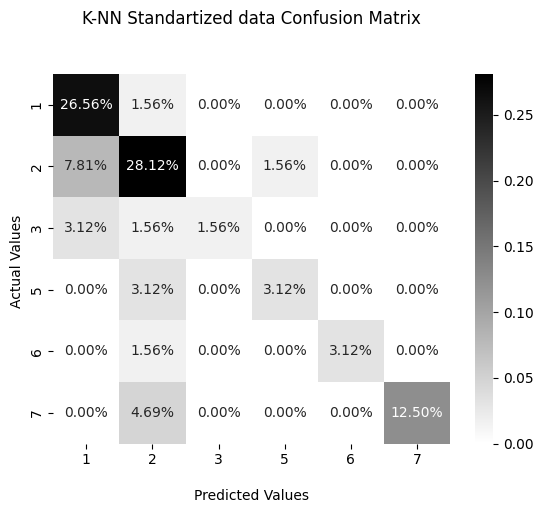

In [ ]:
cf_matrix_knnc = confusion_matrix(y_test, y_pred_std)
print(cf_matrix_knnc)


ax = sns.heatmap(cf_matrix_knnc/np.sum(cf_matrix_knnc), annot=True, fmt='.2%', cmap='binary', annot_kws={"size": 10})
ax.set_title('K-NN Standartized data Confusion Matrix\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['1','2', '3', '5', '6', '7'])
ax.yaxis.set_ticklabels(['1','2', '3', '5', '6', '7'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:
knn_mm = KNeighborsClassifier(n_neighbors=6, weights='distance')
knn_mm.fit(X_train_mm_scal, y_train)
y_pred_mm = knn_mm.predict(X_test_mm_scal)
accuracy_score(y_test, y_pred_mm)

0.78125

In [ ]:
balanced_accuracy_score(y_test, y_pred_mm)

0.6883417508417509

[[17  1  0  0  0  0]
 [ 4 19  0  1  0  0]
 [ 1  1  2  0  0  0]
 [ 0  2  0  2  0  0]
 [ 0  1  0  0  2  0]
 [ 0  2  0  1  0  8]]


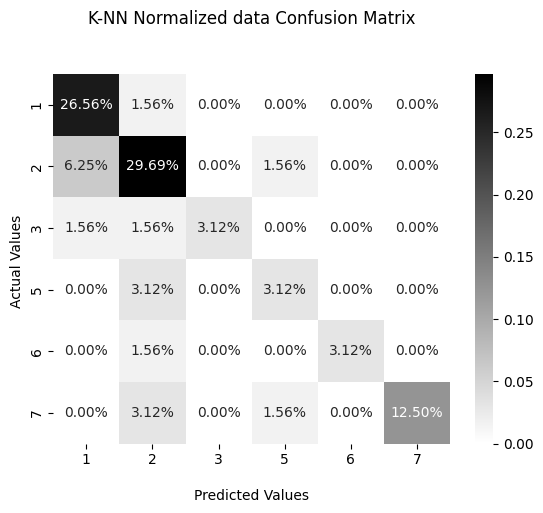

In [ ]:
cf_matrix_knnc = confusion_matrix(y_test,y_pred_mm)
print(cf_matrix_knnc)
ax = sns.heatmap(cf_matrix_knnc/np.sum(cf_matrix_knnc), annot=True, fmt='.2%', cmap='binary', annot_kws={"size": 10})
ax.set_title('K-NN Normalized data Confusion Matrix\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['1','2', '3', '5', '6', '7'])
ax.yaxis.set_ticklabels(['1','2', '3', '5', '6', '7'])

## Display the visualization of the Confusion Matrix.
plt.show()

In [ ]:

knn_robust = KNeighborsClassifier(n_neighbors=6, weights='distance')
knn_robust.fit(X_train_robust, y_train)
y_pred_robust = knn_robust.predict(X_test_robust)
accuracy_score(y_pred_robust,y_test)

0.734375

In [ ]:
balanced_accuracy_score(y_test, y_pred_robust)

0.6304713804713805

[[16  2  0  0  0  0]
 [ 5 18  0  1  0  0]
 [ 2  1  1  0  0  0]
 [ 0  2  0  2  0  0]
 [ 0  1  0  0  2  0]
 [ 1  2  0  0  0  8]]


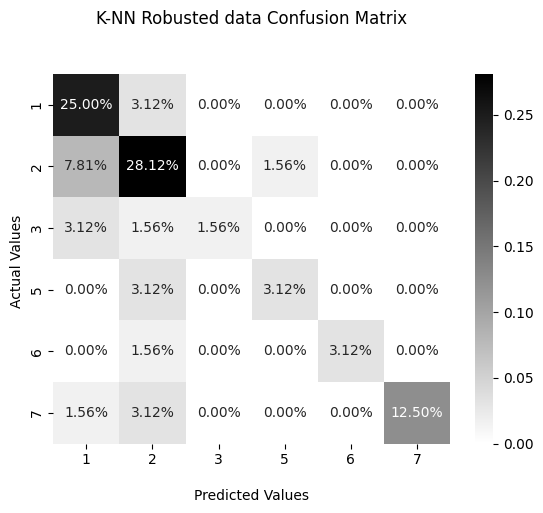

In [ ]:
cf_matrix_knnc = confusion_matrix(y_test,y_pred_robust)
print(cf_matrix_knnc)
ax = sns.heatmap(cf_matrix_knnc/np.sum(cf_matrix_knnc), annot=True, fmt='.2%', cmap='binary', annot_kws={"size": 10})
ax.set_title('K-NN Robusted data Confusion Matrix\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['1','2', '3', '5', '6', '7'])
ax.yaxis.set_ticklabels(['1','2', '3', '5', '6', '7'])

## Display the visualization of the Confusion Matrix.
plt.show()

ну собстенно прям выбросов не было, и этот способ маштабирования ничем не помог.

In [ ]:
results = []
models = {
    'Без маштабирования': y_pred,
    'Стандартизация': y_pred_std,
    'Нормализацияя': y_pred_mm,
    'Robust Scaling': y_pred_robust
}

for name, y_pred in models.items():
    results.append({
        'Спосаб маштабирования': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1-score': f1_score(y_test, y_pred, average='macro')
    })

df_metrics = pd.DataFrame(results)
df_metrics

,Спосаб маштабирования,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,Без маштабирования,0.734375,0.630471,0.837607,0.630471,0.682573
1,Стандартизация,0.750000,0.639731,0.844551,0.639731,0.690510
2,Нормализацияя,0.781250,0.688342,0.833916,0.688342,0.736462
3,Robust Scaling,0.734375,0.630471,0.837607,0.630471,0.682573


Нормализация выигрывает по метрикам. Также стандартизация выигрывает по Precision = TP / (TP + FN), но поскольку отличие в 1 процент, то подходящим спосбом по маштабированию будем считать Нормализацию.

В 4 пункте были обучены классификаторы с разными подходами к маштабированию и все на 6 соседях. Подумав и протестировав на 1 примере стало также ясно, что weights='distance' дает лучший результат чем weights='uniform'

## 5. Подбор гиперпараметров

У подхода через кроссвалидацию имеется огромная проблема - есть класс на 6 обькетов в обучающей выборке, никто не грантирует, что эти 6 обьектов попадут и в валиадционную выборку и в остаток, и так на каждом шаге кросс-валидации

accuracy_score0.8125
balancec_accuracy_score0.7716750841750842
Best Score:0.7048364153627311
Best Parameters: {'metric': 'manhattan', 'n_neighbors': np.int64(5)}
[[17  1  0  0  0  0]
 [ 4 19  0  1  0  0]
 [ 2  0  2  0  0  0]
 [ 0  0  0  4  0  0]
 [ 0  1  0  0  2  0]
 [ 0  2  0  1  0  8]]


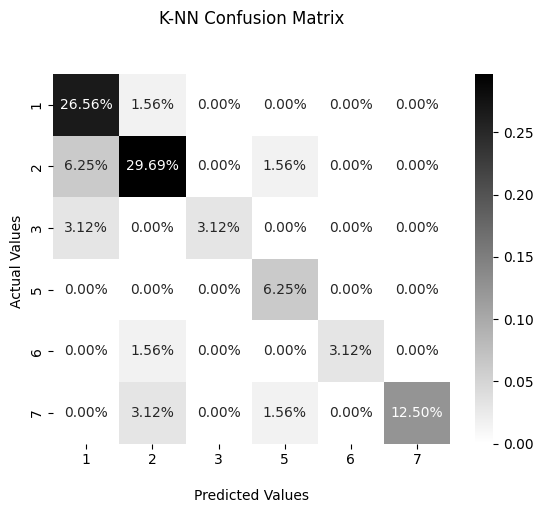

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold


skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

param_grid = {'n_neighbors':np.arange(1,10), 'metric':['euclidean','manhattan' ,'minkowski']}
knn = KNeighborsClassifier(weights='distance')
knn_cv = GridSearchCV(knn,param_grid, cv=skf ,scoring='accuracy')
knn_cv.fit(X_train_mm_scal,y_train)


y_pred_knn_cv = knn_cv.predict(X_test_mm_scal)


print("accuracy_score" + str(accuracy_score(y_test, y_pred_knn_cv)))

print("balancec_accuracy_score" + str(balanced_accuracy_score(y_test, y_pred_knn_cv)))
print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

cf_matrix_knn_cv = confusion_matrix(y_test, y_pred_knn_cv)
print(cf_matrix_knn_cv)

ax = sns.heatmap(cf_matrix_knn_cv/np.sum(cf_matrix_knn_cv), annot=True, fmt='.2%', cmap='binary', annot_kws={"size": 10})
ax.set_title('K-NN Confusion Matrix\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');


## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['1','2', '3', '5', '6', '7'])
ax.yaxis.set_ticklabels(['1','2', '3', '5', '6', '7'])

## Display the visualization of the Confusion Matrix.
plt.show()

по итогу GridSearchCV с использованием StratifiedKFold который сохраняет процентное соотношение классов по выборке по сравнению с ручным подбором результат 81%, на 10 процентов лучше чем подбор пальцем

На всякий случай перепроверка выбора метода нормализации как дающего наивысшую оценку

Best Score:0.6842105263157895
accuracy_score: 0.703125
Best Parameters: {'metric': 'manhattan', 'n_neighbors': np.int64(1)}


d:\ml_course_hw\ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Best Score:0.7046586059743956
accuracy_score: 0.71875
Best Parameters: {'metric': 'manhattan', 'n_neighbors': np.int64(6)}
Best Score:0.7048364153627311
accuracy_score: 0.8125
Best Parameters: {'metric': 'manhattan', 'n_neighbors': np.int64(5)}
Best Score:0.6913229018492176
accuracy_score: 0.734375
Best Parameters: {'metric': 'manhattan', 'n_neighbors': np.int64(9)}


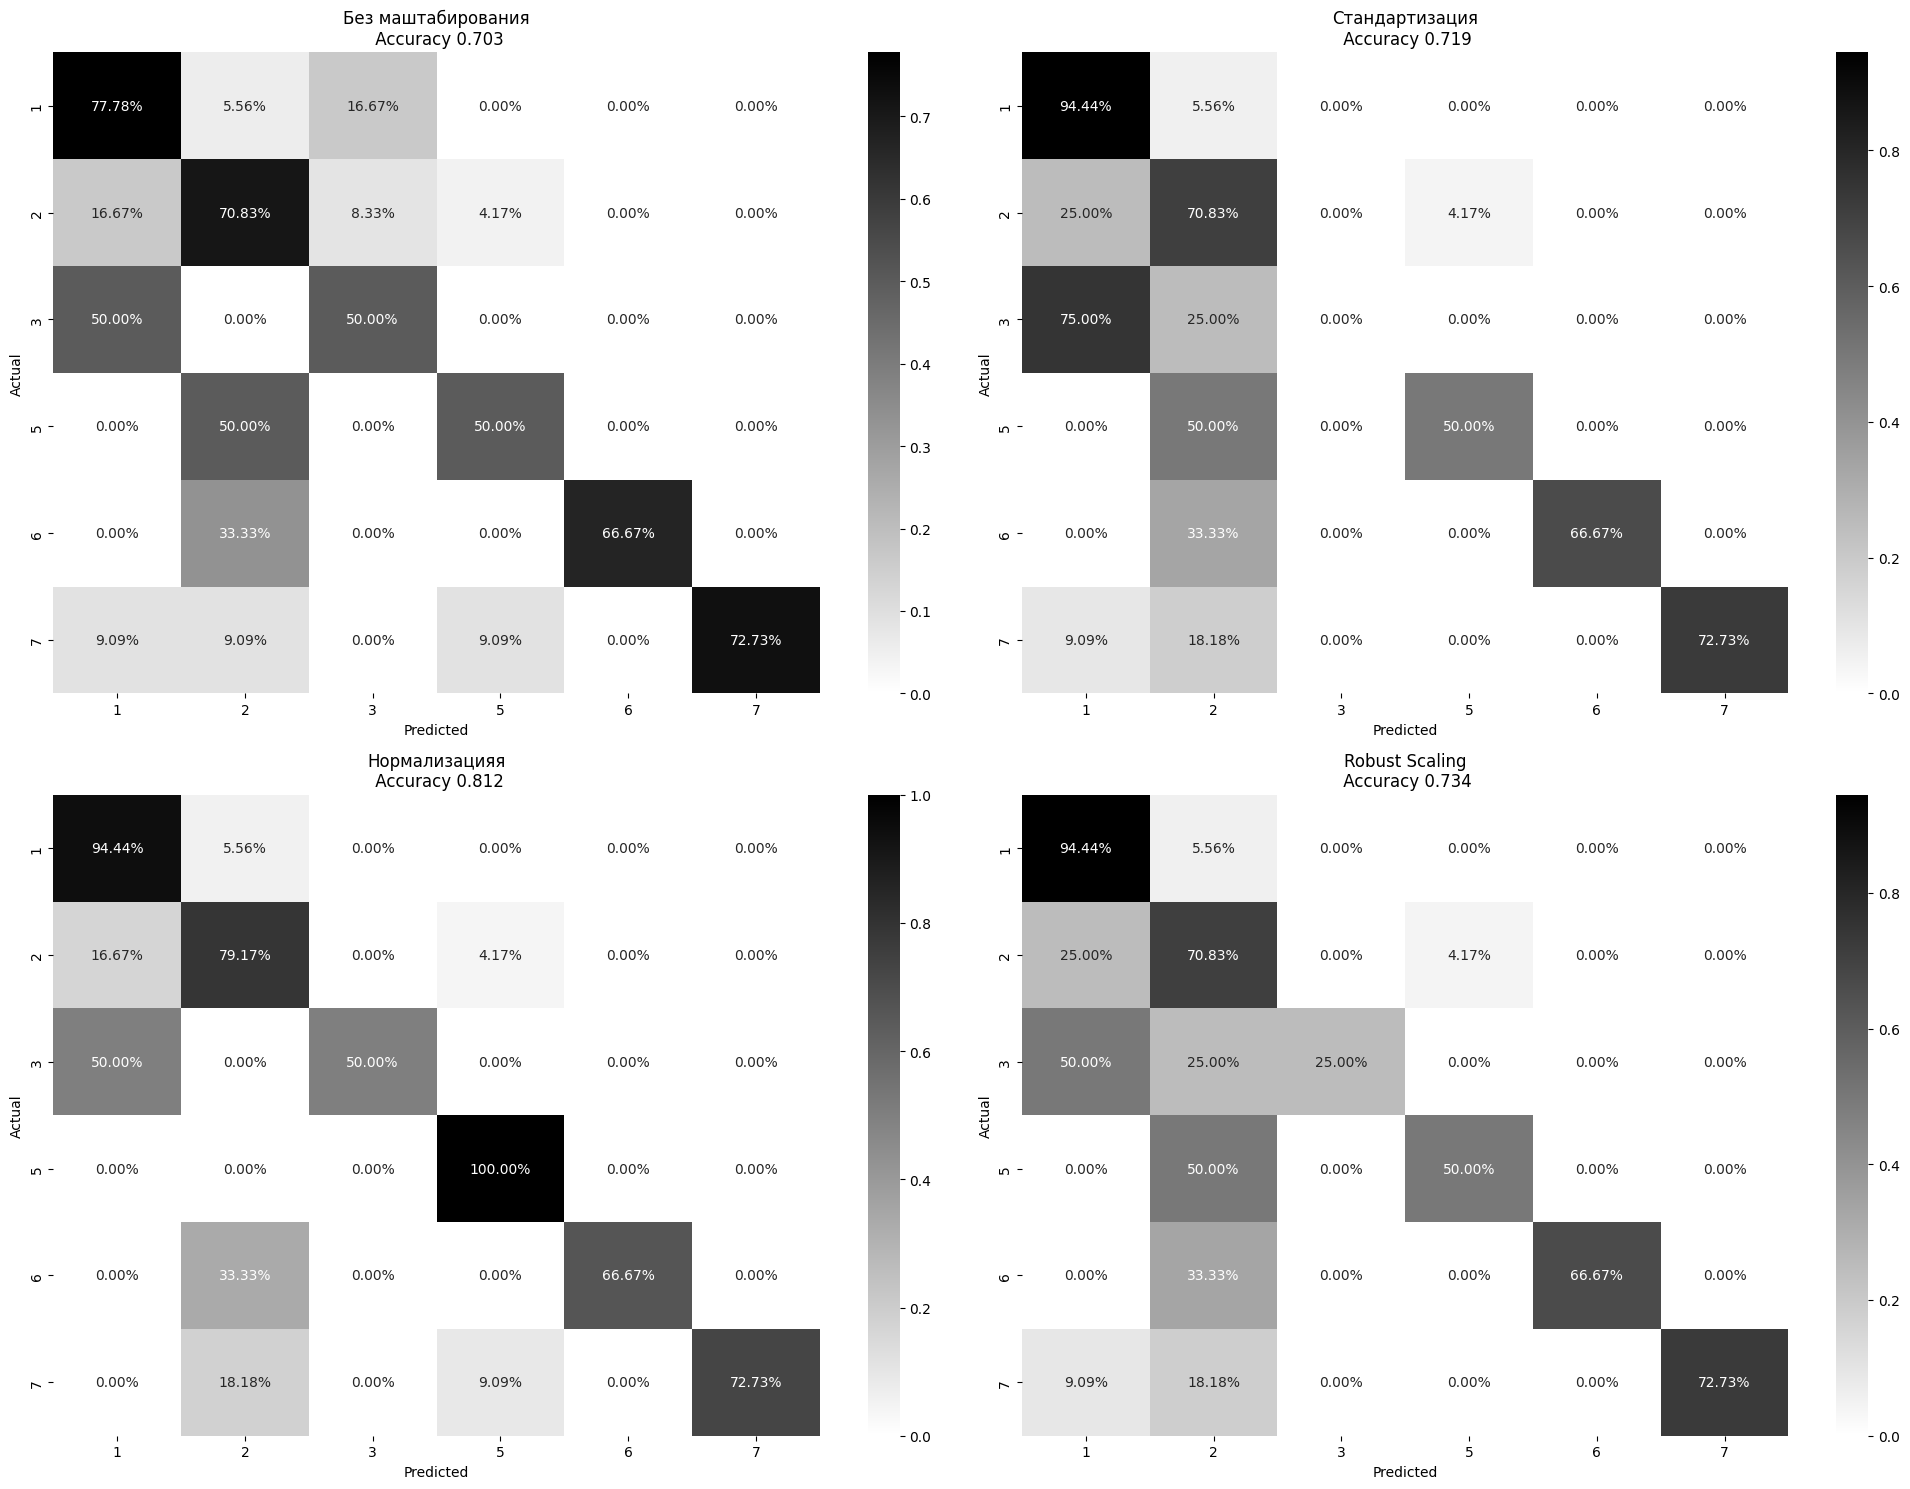

,Спосаб маштабирования,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,metrics,neighbors
0,Без маштабирования,0.703125,0.646675,0.704185,0.646675,0.660470,manhattan,1
1,Стандартизация,0.718750,0.591120,0.667438,0.591120,0.612904,manhattan,6
2,Нормализацияя,0.812500,0.771675,0.871981,0.771675,0.791092,manhattan,5
3,Robust Scaling,0.734375,0.632786,0.838141,0.632786,0.682432,manhattan,9


In [ ]:
from sklearn.pipeline import Pipeline

scalers = {
    'Без маштабирования': None,
    'Стандартизация': StandardScaler(),
    'Нормализацияя': MinMaxScaler(),
    'Robust Scaling': RobustScaler()
}
results = []


plt.figure(figsize = (20, 15))

for i, (name, scaler) in enumerate(scalers.items(), 1):    
    
    if scaler:
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled = X_train
        X_test_scaled = X_test
    
    skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
    param_grid = {
        'n_neighbors': np.arange(1, 10),
        'metric': ['euclidean', 'manhattan', 'minkowski']
    }
    knn = KNeighborsClassifier(weights='distance')
    knn_cv = GridSearchCV(knn,param_grid, cv=skf ,scoring='accuracy')
    knn_cv.fit(X_train_scaled,y_train)

    y_pred_knn_cv = knn_cv.predict(X_test_scaled)

    results.append({
        'Спосаб маштабирования': name,
        'Accuracy': accuracy_score(y_test, y_pred_knn_cv),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred_knn_cv),
        'Precision': precision_score(y_test, y_pred_knn_cv, average='macro'),
        'Recall': recall_score(y_test, y_pred_knn_cv, average='macro'),
        'F1-score': f1_score(y_test, y_pred_knn_cv, average='macro'),\
        'metrics': str(knn_cv.best_params_.get('metric')),
        'neighbors': str(knn_cv.best_params_.get('n_neighbors'))
    })
   
    print("Best Score:" + str(knn_cv.best_score_))
    print("accuracy_score: " + str( accuracy_score(y_test, y_pred_knn_cv)) )
    print("Best Parameters: " + str(knn_cv.best_params_))

    plt.subplot(2, 2, i)
    cf_matrix = confusion_matrix(y_test, y_pred_knn_cv)
    # Нормалізуем матрыцу для працэнтаў па радках (actual classes)
    sns.heatmap(cf_matrix/np.sum(cf_matrix, axis=1)[:, None], annot=True, fmt='.2%', cmap='binary', annot_kws={"size": 10})
    
    plt.title(f'{name}\n Accuracy {knn_cv.score(X_test_scaled, y_test):.3f}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    labels = ['1','2', '3', '5', '6', '7']
    plt.xticks(np.arange(len(labels))+0.5, labels)
    plt.yticks(np.arange(len(labels))+0.5, labels)


plt.tight_layout()
plt.show()
df_metrics = pd.DataFrame(results)
df_metrics



Подтверждает, что нормализация точно лучше
Также тепловая карта была нормализована по строкам - каждая клетка указвает на recall, чем меньше тем больше обьектов класса не угадала модель

Перепроверка резульатта GridSearchCV через графики
Подбор к соседей и метрики

In [ ]:
neighbors = np.arange(1, 40)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))
knns = []
metrics = ['euclidean','manhattan' ,'minkowski']
results = {m: {'train': np.empty(len(neighbors)), 'test': np.empty(len(neighbors))} for m in metrics}


for i, k in enumerate(neighbors):
    for m in metrics:

        knn = KNeighborsClassifier(n_neighbors=k, metric=m, weights='distance')
        knn.fit(X_train_mm_scal, y_train)
        ##results[m]['train'][i] = balanced_accuracy_score(y_train, y_pred_train)
        #results[m]['test'][i] = balanced_accuracy_score(y_test, y_pred)
        results[m]['train'][i] = knn.score(X_train_mm_scal, y_train)
        results[m]['test'][i] = knn.score(X_test_mm_scal, y_test)

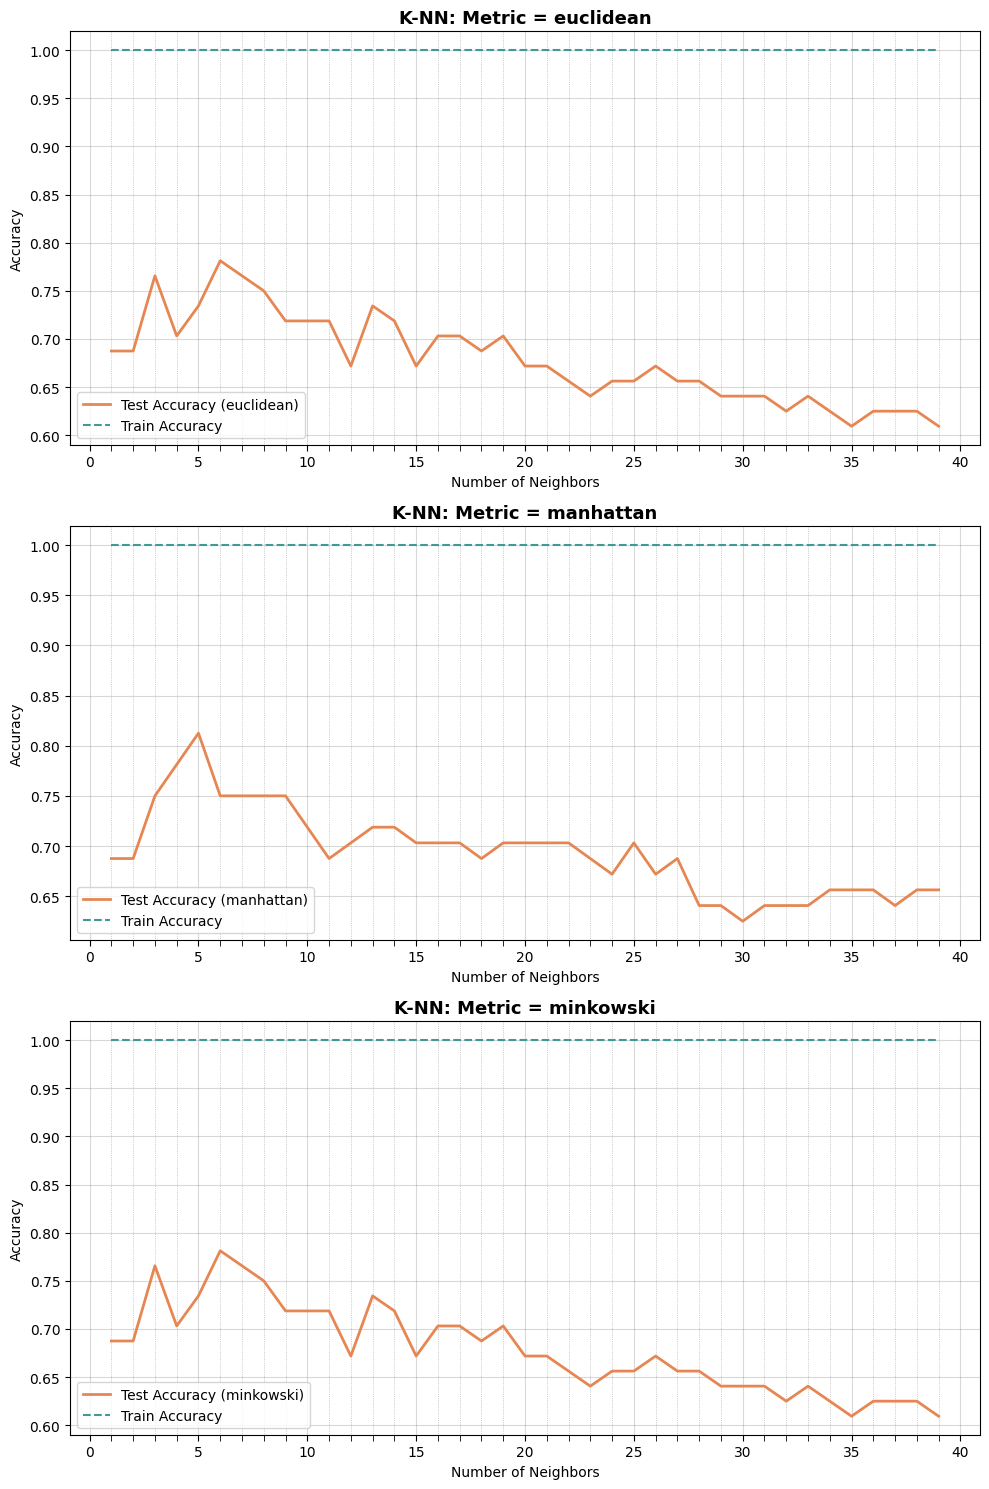

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

for ax, m in zip(axs, metrics):
    ax.plot(neighbors, results[m]['test'], label=f'Test Accuracy ({m})', color='#E68753', lw=2)
    ax.plot(neighbors, results[m]['train'], label='Train Accuracy', linestyle='--', color='#409996')
    ax.legend()
    ax.set_xlabel('Number of Neighbors')
    ax.set_title(f'K-NN: Metric = {m}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(np.arange(0, 41, 1), minor=True)
    for side in ['bottom', 'left']:
        ax.spines[side].set_edgecolor('black')

    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)
    ax.grid(which='major', linestyle='-', linewidth='0.8', color='gray', alpha=0.3)
    ax.tick_params(axis='x', which='both', labelbottom=True , length=4,  bottom=True, color='black', direction='out')
    

plt.tight_layout()
plt.show()

Подтвержаем, манхэттэнская на 5 соседях 81% accuracy, balanced accuracy 0.77

Далее проводится сравнение параметра в knn weights='uniform' и weights='distance', подтверждается вывод прошлого пункта - второй вариант дает выше оценки

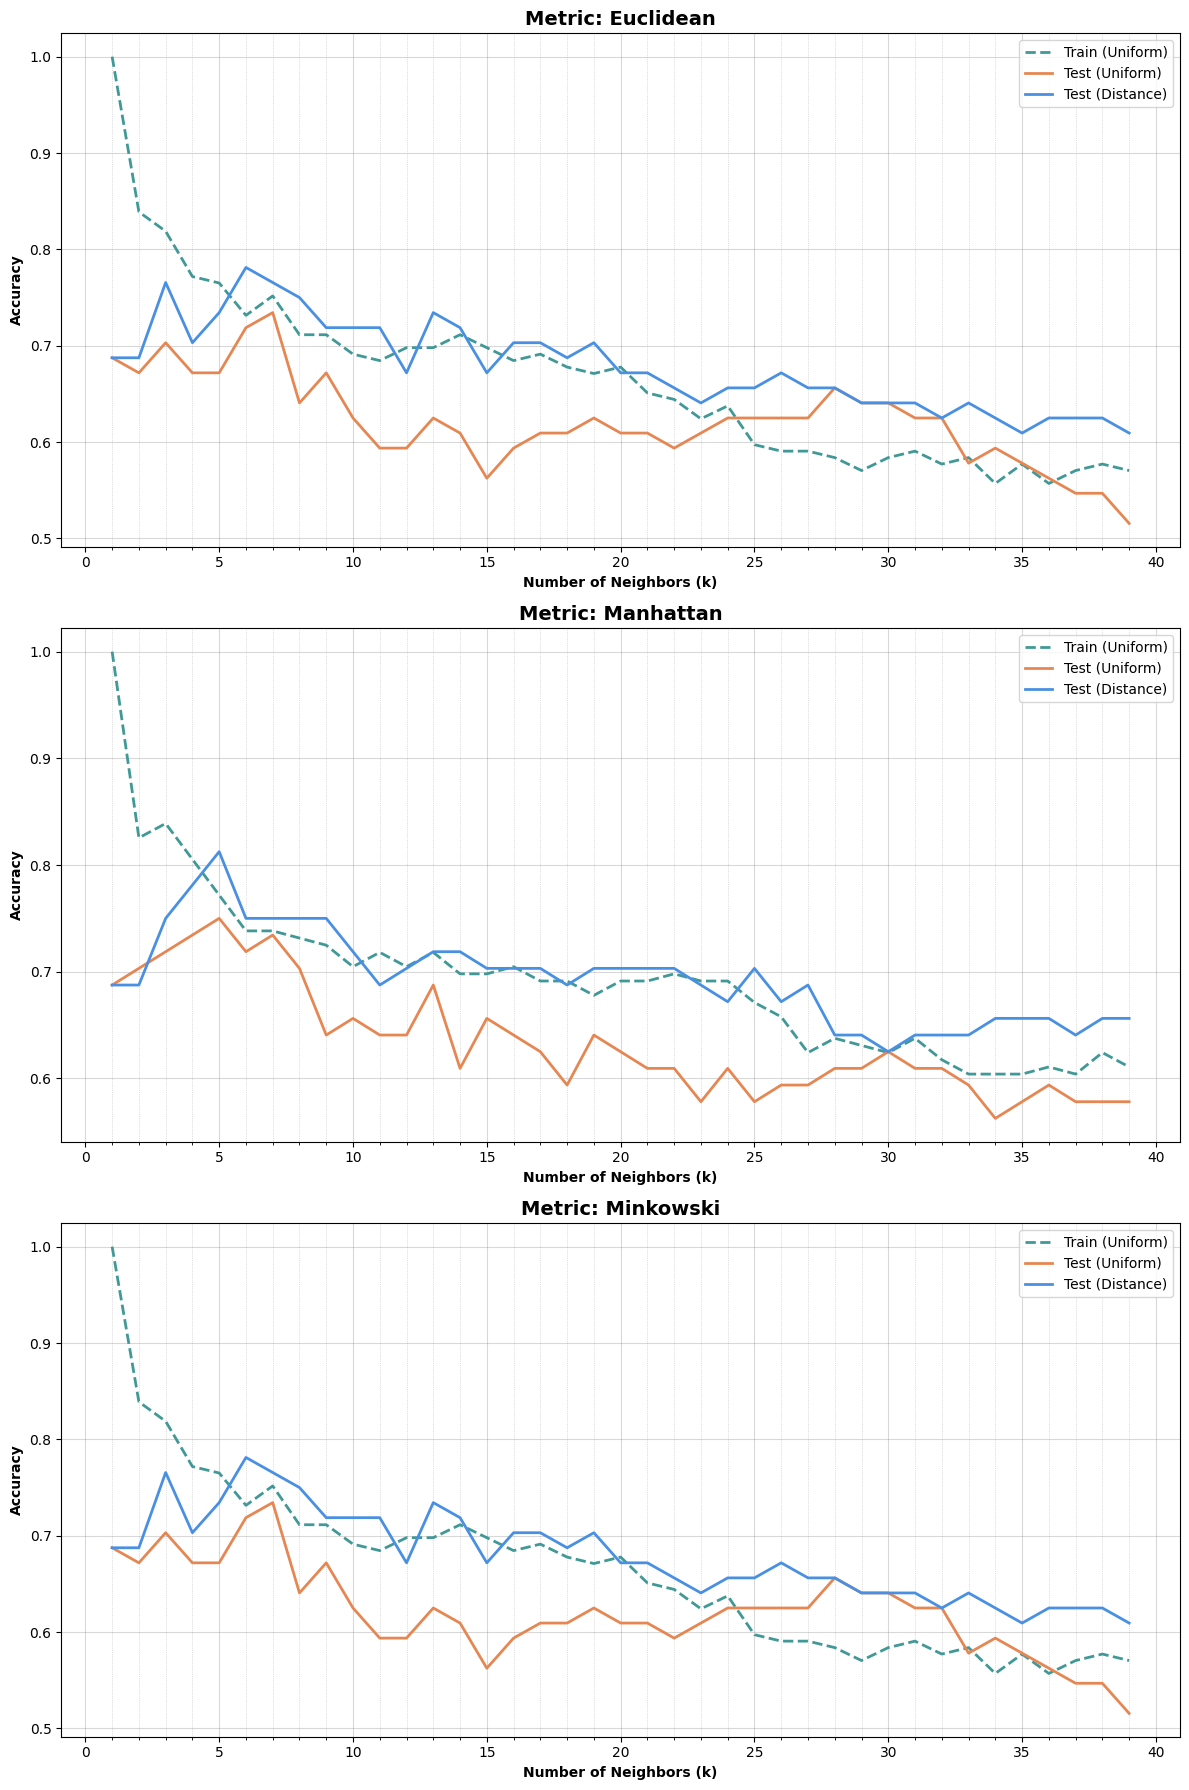

In [ ]:
neighbors = np.arange(1, 40)
metrics = ['euclidean', 'manhattan', 'minkowski']
weights_types = ['uniform', 'distance']


fig, axs = plt.subplots(3, 1, figsize=(12, 18))

for i, m in enumerate(metrics):
    ax = axs[i]
    
    # Спісы для захавання вынікаў для кожнага k
    train_uni = []
    test_uni = []
    test_dist = []
    
    for k in neighbors:
        # 1. Варыянт Uniform
        knn_u = KNeighborsClassifier(n_neighbors=k, metric=m, weights='uniform')
        knn_u.fit(X_train_mm_scal, y_train)
        train_uni.append(knn_u.score(X_train_mm_scal, y_train))
        test_uni.append(knn_u.score(X_test_mm_scal, y_test))
        
        # 2. Варыянт Distance
        knn_d = KNeighborsClassifier(n_neighbors=k, metric=m, weights='distance')
        knn_d.fit(X_train_mm_scal, y_train)
        test_dist.append(knn_d.score(X_test_mm_scal, y_test))
    
    # Малюем 3 лініі
    ax.plot(neighbors, train_uni, label='Train (Uniform)', color='#409996', linestyle='--', lw=2)
    ax.plot(neighbors, test_uni, label='Test (Uniform)', color='#E68753', lw=2)
    ax.plot(neighbors, test_dist, label='Test (Distance)', color='#4A90E2', lw=2)
    
    # Настройкі графіка
    ax.set_title(f'Metric: {m.capitalize()}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_xlabel('Number of Neighbors (k)', fontweight='bold')
    
    # Стылізацыя восяў (вашы налады)
    ax.set_xticks(np.arange(0, 41, 5))
    ax.set_xticks(np.arange(0, 41, 1), minor=True)
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray', alpha=0.5)
    ax.grid(which='major', linestyle='-', linewidth='0.8', color='gray', alpha=0.3)
    ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()

Итог
- метрика manhattan
- соседей 5
- нормализация данных 

дают результат 	
- Accuracy: 0.812500
- Balanced Accuracy: 0.771675
- Precision: 0.871981
- Recall: 0.771675
- F1-score: 0.791092


Однозначно определяются классы :  1 и 5, класс 3 в половине случаев путают с классом 1, а тк класс 3  сильно меньше класса 1 (19 vs 70+), то все не так уж и хорошо. Самый немногочисленный 6 класс (9 значений) в трети случаях путают с большим 2 - вообще плохо очень даже, однако такой результат скорее всего никак не улучшить.

по итогу возможно knn и не в состоянии хорошо решить эту задачу и возможно это было еще понятно на анализе данных, когда все обьекты скучкованны по большинству признаков,и датасет маленький, несбалансированный.